# Detecting Tipping Points with Ammonyte's Ruptures Wrapper

_Description:_ Detect transitions using the Pelt change-point detection algorithm with an l2 cost function, and evaluate against known events using precision, recall, and F1 score.

## Overview

This notebook demonstrates the application of **change-point detection algorithms** from the Ammonyte's rupture wrapper for identifying abrupt climate transitions in paleoclimate time series. Rupture detection provides powerful statistical methods for detecting structural breaks and regime shifts in climate systems.

**Notebook Structure:**
- Complete workflow applied to NGRIP ice core data (validation against known DO events)

## Scientific Background

**Change-point detection** is a statistical framework for identifying points in time where the statistical properties of a time series change abruptly. It is used to detect structural breaks, regime shifts, and tipping points in climate systems.

The approach works by:
- Partitioning time series into homogeneous segments using **search algorithms**
- Measuring within-segment variability using **cost functions**
- Balancing model fit against complexity through a penalty parameter


### Available Algorithms

#### 1. **Pelt (Pruned Exact Linear Time)**
- **Type**: Exact optimal detection with intelligent pruning
- **Complexity**: O(n) for many practical cases
- **Advantage**: Automatically determines the optimal number of change-points
- **How it works**: Uses dynamic programming with pruning to eliminate suboptimal solutions
- **Reference**: Killick, R., Fearnhead, P., & Eckley, I. (2012). Optimal detection of changepoints with a linear computational cost. *Journal of the American Statistical Association*, 107(500), 1590–1598.

#### 2. **Binseg (Binary Segmentation)**
- **Type**: Sequential greedy algorithm
- **Complexity**: O(n log n)
- **Advantage**: Fast and intuitive
- **How it works**: Recursively splits the data at the most significant change-point
- **References**: Bai, J. (1997). Estimating multiple breaks one at a time. *Econometric Theory*, 13(3), 315–352. Fryzlewicz, P. (2014). Wild binary segmentation for multiple change-point detection. *The Annals of Statistics*, 42(6), 2243–2281.

#### 3. **BottomUp**
- **Type**: Hierarchical merging approach
- **Complexity**: O(n²) (worst case)
- **How it works**: Starts with many change-points and iteratively merges adjacent segments
- **References**: Keogh, E., et al. (2001). An online algorithm for segmenting time series. *Proceedings of the IEEE International Conference on Data Mining (ICDM)*, 289–296. Fryzlewicz, P. (2007). Unbalanced Haar technique for nonparametric function estimation. *Journal of the American Statistical Association*, 102(480), 1318–1327.

#### 4. **Dynp (Dynamic Programming)**
- **Type**: Exact optimal detection
- **Complexity**: O(n²)
- **Advantage**: Guaranteed globally optimal solution
- **Disadvantage**: Very slow for large datasets
- **Reference**: Jackson, B., et al. (2005). An algorithm for optimal partitioning of data on an interval. *IEEE Signal Processing Letters*, 12(2), 105–108.

#### 5. **Window**
- **Type**: Local comparison approach
- **Complexity**: O(n)
- **Advantage**: Fast and simple
- **How it works**: Slides a window across the data and compares statistics on either side to detect local discrepancies
- **Reference**: Truong, C., Oudre, L., & Vayatis, N. (2020). Selective review of offline change point detection methods. *Signal Processing*, 167, 107299.

#### 6. **KernelCPD**
- **Type**: Kernel-based detection
- **Advantage**: Detects complex, nonlinear distribution changes without parametric assumptions
- **How it works**: Uses kernel methods (like RBF) to measure similarity between segments in a high-dimensional feature space
- **References**: Celisse, A., et al. (2018). New efficient algorithms for multiple change-point detection with reproducing kernels. *Computational Statistics & Data Analysis*, 128, 200–220. Arlot, S., Celisse, A., & Harchaoui, Z. (2019). A kernel multiple change-point algorithm via model selection. *Journal of Machine Learning Research*, 20(162), 1–56.

### Cost Functions

Different cost functions measure how "different" segments are from each other:

#### Mean-based
- **l1**: Detects mean shifts using absolute deviations 
- **l2**: Detects mean shifts using squared deviations

#### Distribution-based
- **normal**: Detects changes in mean and variance (assumes Gaussian data)
- **rbf**: Detects all distribution changes — mean, variance, shape (kernel-based)
- **rank**: Detects distribution changes using rank statistics (non-parametric, robust)

#### Trend-based
- **linear**: Detects changes in linear trend (slope changes)
- **clinear**: Detects piecewise linear trends with continuous connections between segments

#### Specialized
- **ar**: Detects changes in AR model coefficients for temporally dependent data
- **mahalanobis**: Detects changes in multivariate mean and covariance using Mahalanobis distance
- **cosine**: Detects changes in the orientation or shape of multivariate signals (cosine similarity-based)

### Penalty Parameter
The **penalty parameter** controls the complexity-accuracy trade-off:
- **Higher penalty** → Fewer change-points (simpler model, may miss subtle transitions)
- **Lower penalty** → More change-points (complex model, may detect noise as transitions)
- Selection often requires domain knowledge or validation against known events

In [1]:
# Import libraries and packages
import ammonyte as amt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import psutil
import os
import gc

### Load the NGRIP Dataset for Tipping Point Analysis

### Dataset Overview
The **North Greenland Ice Core Project (NGRIP)** dataset contains high-resolution paleoclimate proxy data from Greenland ice cores. This dataset is particularly valuable for studying abrupt climate transitions and tipping points in the Earth's climate system.

**Key Dataset Features:**
- **Proxy Variable**: $\mathrm{\delta^{18}O}$ isotope measurements
- **Units**: per mil 
- **Time Scale**: Thousands of years before present (kyr b2k)

In [2]:
# Load NGRIP dataset
ngrip = amt.Series.from_csv('../ammonyte/data/NGRIP.csv')

Time axis values sorted in ascending order
Time axis values sorted in ascending order


### Dataset Metadata Summary

Display key metadata information from the loaded NGRIP time series to understand the dataset characteristics.

In [3]:
# Display metadata
print(f"Loaded NGRIP dataset: {ngrip.label}")
print(f"Time range: {ngrip.time.min():.2f} - {ngrip.time.max():.2f} {ngrip.time_unit}")
print(f"Number of data points: {len(ngrip.time)}")
print(f"Value range: {ngrip.value.min():.2f} - {ngrip.value.max():.2f} {ngrip.value_unit}")
print(f"Evenly spaced: {ngrip.is_evenly_spaced()}")

Loaded NGRIP dataset: NGRIP Ice Core Data
Time range: 0.05 - 122.27 kyr b2k
Number of data points: 6112
Value range: -46.50 - -32.11 ‰
Evenly spaced: True


### NGRIP $\mathrm{\delta^{18}O}$ Record Visualization
The plot below shows the complete NGRIP ice core record, where:
- **X-axis**: Time in thousands of years before present (kyr b2k)
- **Y-axis**: $\mathrm{\delta^{18}O}$ isotope values in per mil 
- **Interpretation**: More negative values indicate colder conditions

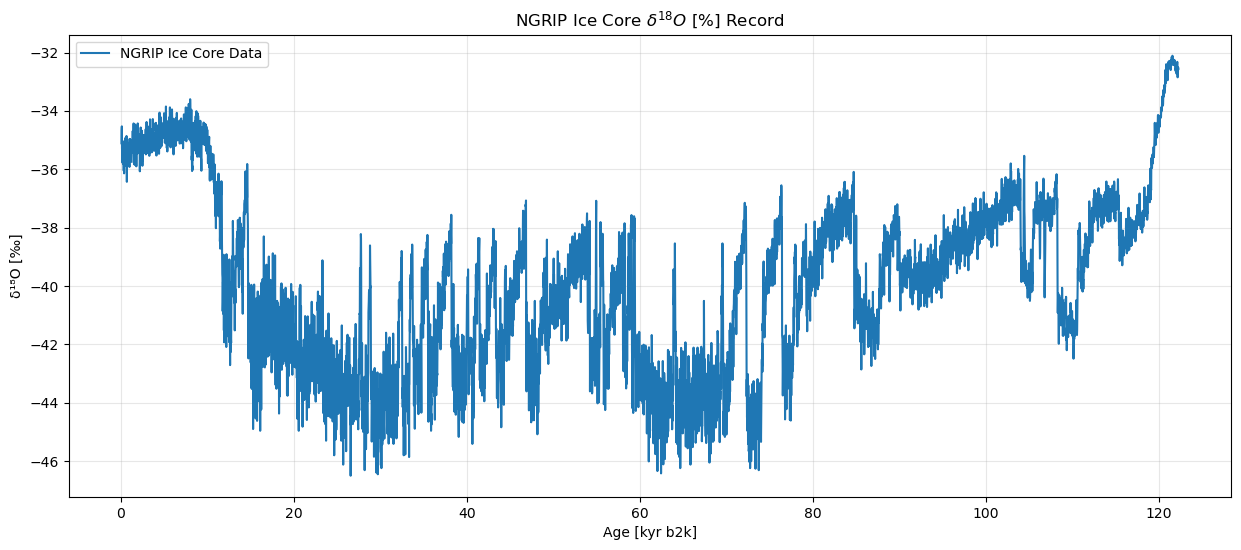

In [4]:
# The NGRIP series is already loaded with proper metadata
#plot the time series to visualize the data
fig, ax = ngrip.plot(figsize=(15, 6))
ax.set_title('NGRIP Ice Core $\delta^{18}O\ [\%]$ Record')
ax.grid(True, alpha=0.3)

# Main Rupture Analysis

This section demonstrates the complete Rupture workflow for detecting climate transitions in the NGRIP dataset. We use **Pelt algorithm with l2 cost function** as the recommended default configuration.

**Workflow Steps:**
1. Apply Rupture detection with recommended settings
2. Examine detected transitions
3. Visualize results on NGRIP time series
4. Load known Dansgaard-Oeschger (DO) events for validation
5. Quantitative validation against main DO events
6. Visualization of detected vs. known events

## Step 1: Apply Rupture Detection (Default Configuration)

**Recommended Configuration:**
- **Algorithm**: `Pelt`
- **Cost function**: `l2`
- **Penalty**: `10` 


In [5]:
# Apply Rupture detection with recommended settings
transitions = ngrip.ruptures(algo='Pelt', cost='l2', pen=10)

## Step 2: Results Summary

The output shows the number of detected change-points and details for each transition including timing, direction, and location in the time series.

In [6]:
# Print transition results
print(transitions)
detected_times = transitions.jump_times[~np.isnan(transitions.jump_times)]

Deterministic Transition Detection Results - NGRIP Ice Core Data | ruptures
+----------+---------------------+----------------+------------------+---------------------+
| Method   |   Total Transitions |   Upward Jumps |   Downward Jumps | Series Label        |
+==========+=====================+================+==================+=====================+
| ruptures |                 108 |             41 |               67 | NGRIP Ice Core Data |
+----------+---------------------+----------------+------------------+---------------------+

Transition Details:
  1. Time: 2.77 kyr b2k, Direction: Downward, breakpoint_indices: 136.0000
  2. Time: 10.21 kyr b2k, Direction: Upward, breakpoint_indices: 508.0000
  3. Time: 10.87 kyr b2k, Direction: Upward, breakpoint_indices: 541.0000
  4. Time: 11.69 kyr b2k, Direction: Upward, breakpoint_indices: 582.0000
  5. Time: 12.77 kyr b2k, Direction: Downward, breakpoint_indices: 636.0000
  6. Time: 13.29 kyr b2k, Direction: Downward, breakpoint_indices

## Step 3: Transition Visualization

Display the NGRIP time series with detected change-points marked by vertical lines:
- **Red lines**: Upward transitions (warming events)
- **Blue lines**: Downward transitions (cooling events)

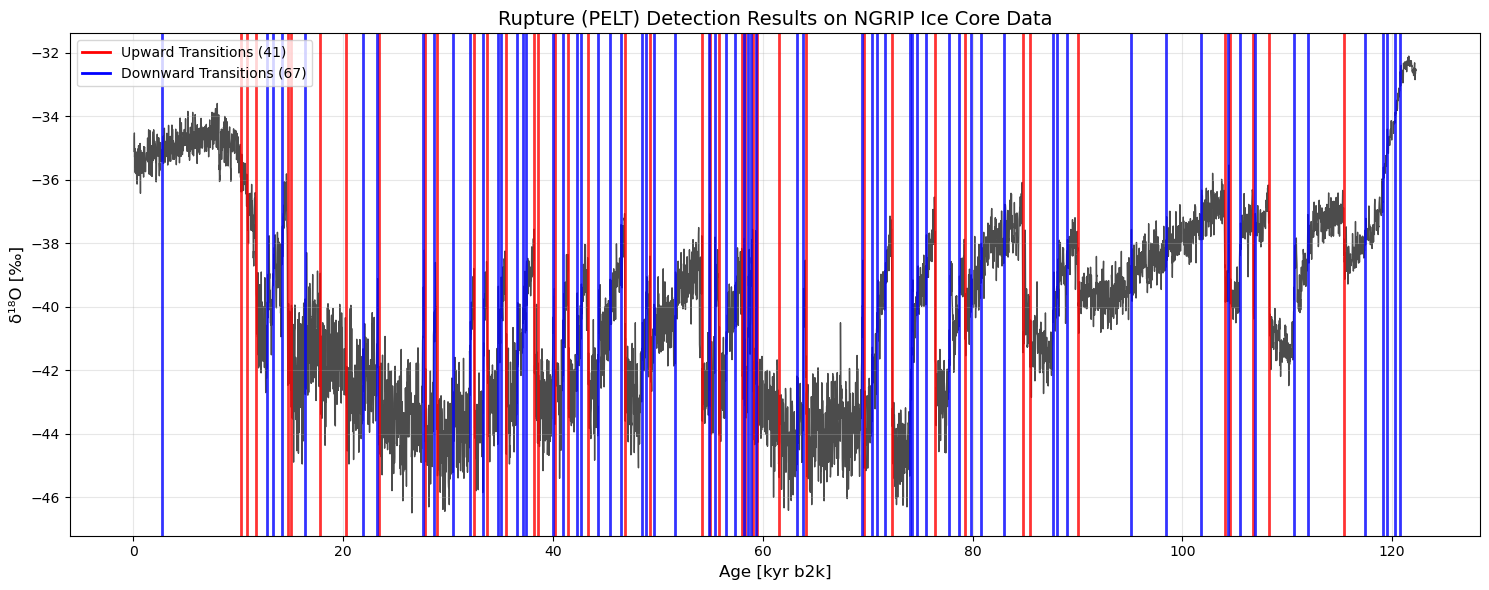

In [7]:
# Visualize detected transitions
fig, ax = plt.subplots(figsize=(15, 6))
transitions.plot(ax=ax, title='Rupture (PELT) Detection Results on NGRIP Ice Core Data')
plt.tight_layout()
plt.show()

## Step 4: Load Known DO Events for Validation

To validate our detection results, we compare against published **Dansgaard-Oeschger (DO) events**, well-documented abrupt climate transitions in the NGRIP record. These events represent rapid warming episodes followed by gradual cooling during the last glacial period.

**Reference:** [Rasmussen et al.(2014)]((https://doi.org/10.1016/j.quascirev.2014.09.007)), A stratigraphic framework for abrupt climatic changes during the Last Glacial period based on three synchronized Greenland ice-core records

**Note:** Event timings are subject to chronological uncertainties from annual layer counting and dating techniques, which increase with depth.


In [8]:
# Define D/O event chronologies as numpy arrays for analysis
do_events = pd.read_csv('../ammonyte/data/DO_events.csv', comment = '#')

main_do_events = do_events['main_kyr_b2k'].dropna().values
print(len(main_do_events)) # The length of main DO events 

all_do_events = do_events['all_kyr_b2k'].dropna().values
print(len(all_do_events))  # The length of all DO events


25
73


## Step 5: Quantitative Validation Against Known DO Events

Dansgaard-Oeschger (DO) events are abrupt **warming** transitions, so we compare only detected **upward** transitions against the 25 main DO onset times from Rasmussen et al. (2014), using a ±500-year tolerance window.

In [9]:
# Filter to upward transitions only (DO events are abrupt warmings)
upward_mask = transitions.jump_values == 1
detected_upward = transitions.jump_times[upward_mask]
detected_upward = detected_upward[~np.isnan(detected_upward)]

# Evaluate detection performance against main DO events
results = amt.utils.evaluate_detection(detected_upward, main_do_events, tolerance=0.5)
print(results)

Detection Evaluation Metrics
Metrics calculated within tolerance = 0.5

Performance Scores:
+-----------+---------+
| Metric    |   Value |
+===========+=========+
| Precision |  0.3415 |
+-----------+---------+
| Recall    |  0.56   |
+-----------+---------+
| F1 Score  |  0.4242 |
+-----------+---------+

Detection Counts:
+-----------------+---------+
| Category        |   Count |
+=================+=========+
| True Positives  |      14 |
+-----------------+---------+
| False Positives |      27 |
+-----------------+---------+
| False Negatives |      11 |
+-----------------+---------+

Summary:
  Detected: 41 | Ground Truth: 25



## Step 6: Validation Visualization

This plot shows the NGRIP time series with detected **upward** transitions and known Dansgaard-Oeschger (DO) events overlaid. Only upward transitions are shown since DO events are defined as abrupt warming onsets.

- **Red lines**: Detected upward transitions
- **Green dashed lines**: Known DO warming events (Rasmussen et al., 2014)

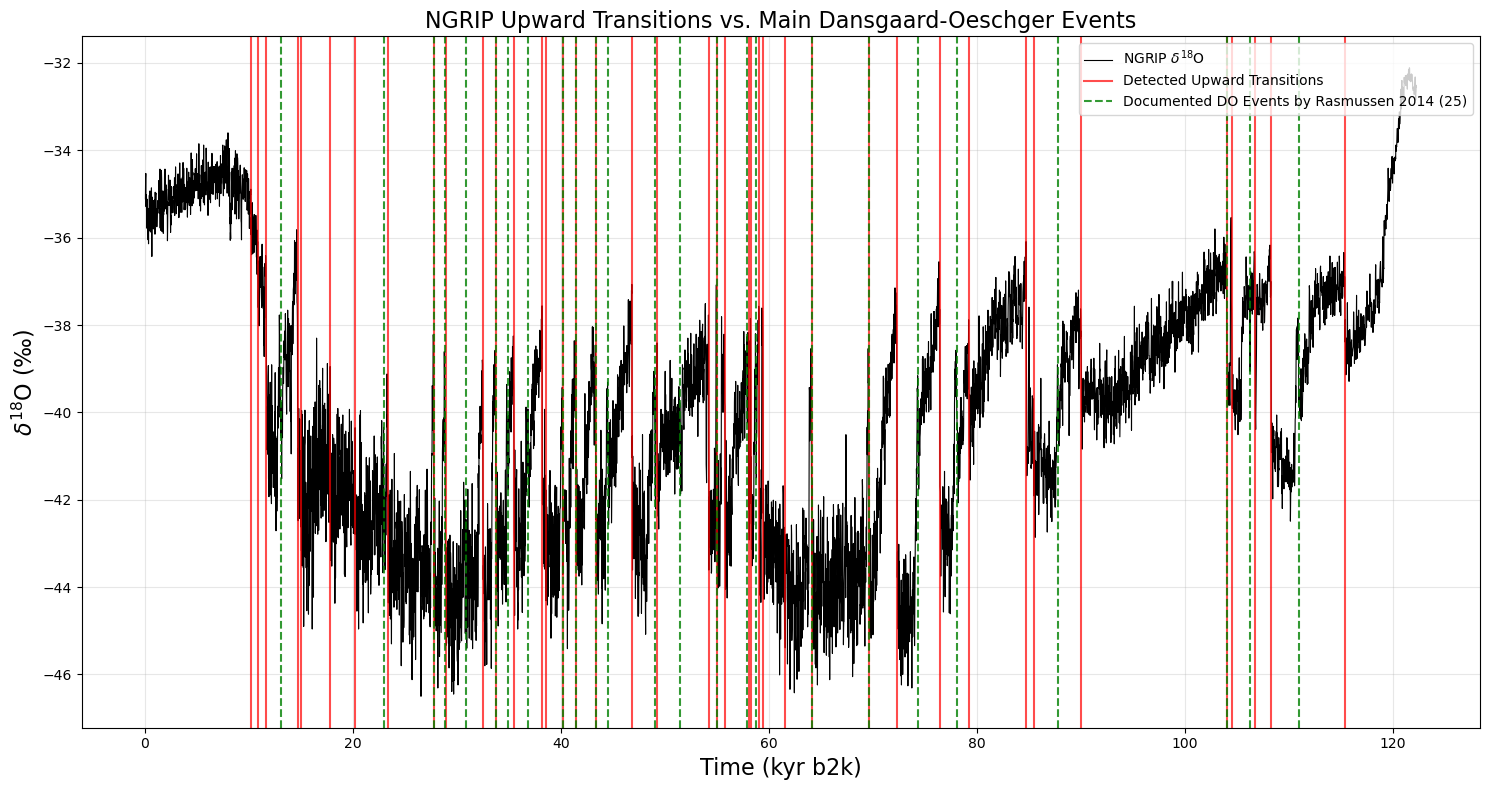

In [10]:
fig, ax = plt.subplots(figsize=(15, 8))
ax.plot(ngrip.time, ngrip.value, color='black', linewidth=0.8, label='NGRIP $\delta^{18}\mathrm{O}$')

# Plot only upward transitions
first_up = True
for t, direction in zip(transitions.jump_times, transitions.jump_values):
    if direction > 0:
        label = 'Detected Upward Transitions' if first_up else None
        ax.axvline(x=t, color='red', alpha=0.7, linewidth=1.5, label=label)
        first_up = False

# Add DO events
for i, event_time in enumerate(main_do_events):
    if i == 0:
        ax.axvline(event_time, color='green', linestyle='--', linewidth=1.5, alpha=0.8,
                label=f'Documented DO Events by Rasmussen 2014 ({len(main_do_events)})')
    else:
        ax.axvline(event_time, color='green', linestyle='--', linewidth=1.5, alpha=0.8)

ax.set_xlabel('Time (kyr b2k)', fontsize=16)
ax.set_ylabel('$\delta^{18}\mathrm{O}$ (‰)', fontsize=16)
ax.set_title('NGRIP Upward Transitions vs. Main Dansgaard-Oeschger Events', fontsize=16)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion

We see that the Pelt algorithm (l2 cost, penalty = 10) is able to identify **14 of 25 (56%)** of the DO warming events documented by [Rasmussen et al. (2014)](https://doi.org/10.1016/j.quascirev.2014.09.007), with a precision of 34% (F1 = 0.42).

**Pros:** Highly flexible, `Series.ruptures()` exposes six search algorithms and multiple cost functions for different data types. Pelt automatically determines the number of change-points, so no fixed count is needed.

**Major drawback:** Like the KS test, ruptures algorithms detect structural breaks in statistical properties (mean, variance). They are well-suited to sharp amplitude shifts but say nothing about the dynamics. For dynamically-sensitive detection, see the [LERM tutorial](LERM_validation.ipynb).

For the original ruptures library, see [Truong et al. (2020)](https://doi.org/10.1016/j.sigpro.2019.107299).